In [1]:
# Importing libraries
import pandas as pd
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler 
import warnings
warnings.filterwarnings('ignore')
import scipy
from sklearn.cluster import KMeans
from PIL import Image
from itertools import combinations

In [2]:
# Importing coordinates
local = pd.read_csv(r"C:\Users\joaoa\Desktop\Doutoramento\Professora\Nova pasta\Todos os Pontos (temperatura)\local.cvs")

# Defining parameters
Y = range(1950, 2023) #1950-2023
K = range(2, 7) # 2-7
T = ["no restriction", "9h-9h"]
H = [1,2,3,4,5,6]

In [3]:
max_precipitations = pd.read_csv(r"D:\Precipitation\by_water_year\max_precipitations_(mm).csv")
max_precipitations

,year,type_of_period,duration,P0000,P0001,P0002,P0003,P0004,P0005,P0006,...,P1047,P1048,P1055,P1056,P1057,P1058,P1059,P1062,P1063,P1064
0,1950_1951,no restriction,1h,8.326463,8.243036,8.805152,9.028085,9.084161,8.476909,7.380027,...,3.436994,3.357664,3.744721,3.943034,3.918417,3.777545,3.583334,4.295899,4.206998,4.134510
1,1950_1951,no restriction,2h,15.106078,16.101751,16.759608,16.780123,16.432732,15.006237,13.470327,...,6.239377,5.898822,7.132474,7.441573,7.321216,7.192655,7.053152,8.147297,7.940779,7.769816
2,1950_1951,no restriction,3h,20.434577,22.103149,22.261806,21.800894,22.388998,21.266129,19.032700,...,7.886067,8.359287,10.383461,10.725383,10.626908,10.405345,10.334227,11.299809,11.242369,11.195865
3,1950_1951,no restriction,4h,23.979615,25.218735,26.281431,26.591893,26.449654,24.742782,22.127772,...,8.817460,9.966318,14.006458,14.470104,13.779424,13.340397,13.321247,14.879042,14.202038,13.961323
4,1950_1951,no restriction,5h,26.202101,28.151052,28.884135,28.930634,28.555889,26.844913,24.644312,...,9.346757,11.343576,16.998954,17.623985,17.085116,16.196122,15.906174,18.063011,17.503629,17.063234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3353,2022_2023,9h-9h,24h,54.779407,84.152669,78.163899,69.087140,61.068974,52.875238,47.976034,...,33.152206,27.432676,23.512300,24.586378,25.095019,25.851524,27.461352,29.078925,29.064724,29.050523
3354,2022_2023,9h-9h,48h,87.853795,110.887036,107.861828,103.527183,96.785700,88.935407,80.281787,...,38.806304,32.095753,46.217747,48.270375,49.124993,49.509700,50.263621,50.270073,50.356567,50.426278
3355,2022_2023,9h-9h,72h,94.963124,117.144329,117.125774,116.913173,110.899793,101.122091,88.095980,...,38.814284,32.113306,47.071073,49.186960,50.157759,50.774843,51.829558,51.357064,51.497780,51.613968
3356,2022_2023,9h-9h,96h,114.451494,142.719587,142.209170,141.910078,135.120828,124.048291,109.234199,...,45.058457,43.492522,67.695491,71.006805,73.210482,74.905513,76.910375,76.315241,77.277005,78.081276


In [4]:
# Collecting all information in one dictionary
dict_max = {"no restriction" : {}, "9h-9h" : {}}

for type_of_period in T: 
    for hours in H:
        dict_max[type_of_period][str(hours) + "h"] = max_precipitations[(max_precipitations["type_of_period"] == type_of_period) & (max_precipitations["duration"] == str(hours) + "h")].iloc[:, 3:].reset_index(drop = True)

In [5]:
seq_clusters = {"no restriction" : {}, "9h-9h" : {}}

for t in T:

    for n in K:
        seq_clusters[t][n] = pd.DataFrame()

    for h in H:
        df = dict_max[t][str(h) + "h"]

        # Standardizing dataframe
        scaler = StandardScaler() 
        stand_precip = scaler.fit_transform(df) 
        stand_precip = pd.DataFrame(stand_precip, columns = df.columns)
        stand_precip = stand_precip*np.sqrt((len(stand_precip)-1)/len(stand_precip))

        # Transposing dataframe
        transp = stand_precip.transpose()

        # Clustering (k-means)
        inertia = []

        for n in K:
            X = stand_precip.transpose()
            kmeans = KMeans(n_clusters = n, max_iter = 1000000000000000, tol = 0.000000000000001, random_state = 42)
            kmeans.fit(X)
            inertia.append(kmeans.inertia_)
            kmeans.labels_ += 1
            transp["clusters_" + str(n) + " | " + str(h) + "h (" + t + ")"] = kmeans.labels_

            # Concatenating clusters   
            seq_clusters[t][n] = pd.concat([seq_clusters[t][n], transp.iloc[:,-1]], axis = 1)


    # Creating a final column with sequence
    for n in K:
        seq_clusters[t][n] = seq_clusters[t][n].astype(str)

        i = 0
        seq_clusters[t][n]["code"] = ""
        for h in H:
            seq_clusters[t][n]["code"] = seq_clusters[t][n]["code"] + seq_clusters[t][n].iloc[:,i]
            i += 1

In [6]:
seq_clusters["no restriction"][3]

,clusters_3 | 1h (no restriction),clusters_3 | 2h (no restriction),clusters_3 | 3h (no restriction),clusters_3 | 4h (no restriction),clusters_3 | 5h (no restriction),clusters_3 | 6h (no restriction),code
P0000,3,3,3,1,1,1,333111
P0001,3,3,3,1,1,1,333111
P0002,3,3,3,1,1,1,333111
P0003,3,3,3,1,1,1,333111
P0004,3,3,3,1,1,1,333111
...,...,...,...,...,...,...,...
P1058,1,1,2,3,3,2,112332
P1059,1,1,2,3,3,2,112332
P1062,1,1,2,3,3,2,112332
P1063,1,1,2,3,3,2,112332


In [7]:
# Deciding most frequent exclusive clusters 
commun_points = {"no restriction" : {}, "9h-9h" : {}}

for n in K:
    for t in T:
        
        # Saving all codes with absolute frequency greater than or equal to 5
        i = 0
        for _ in seq_clusters[t][n].groupby("code")["code"].agg("count").sort_values(ascending = False):
            i += 1
            if seq_clusters[t][n].groupby("code")["code"].agg("count").sort_values(ascending = False)[i] < 5:
                codes = seq_clusters[t][n].groupby("code")["code"].agg("count").sort_values(ascending = False)[0:i]
                break


        # Creating all possible combinations of clusters
        count_list = list(range(0,len(codes)))

        comb = []
        for p in range(1, n+1):
            comb += list(combinations(count_list, p))

        for _ in range(0, len(comb)):
            comb[_] = list(comb[_])
            comb[_].insert(0, 0)
            for element in comb[_][1:]:
                comb[_][0] += codes[element]

        comb = sorted(comb, key = lambda x: x[0], reverse = True)


        # Finding the combination with the highest number of points
        for hip in comb:
            top_lista = []
            aux = seq_clusters[t][n].copy()

            for _ in hip[1:]:
                top_lista.append(codes.index[_])

            aux = aux[aux["code"].isin(top_lista)]
            check_1 = len(aux)

            for top_code in top_lista:
                for index in range(0,len(top_code)):
                    aux = aux[(aux.iloc[:, index] != top_code[index]) | (aux.loc[:, "code"] == top_code)]

            check_2 = len(aux)

            if check_1 == check_2:
                break
        
        # Creating a commun column
        seq_clusters[t][n]["commun"] = "-1"

        for _ in range(0, len(top_lista)):
            seq_clusters[t][n].loc[seq_clusters[t][n]["code"] == top_lista[_], "commun"] = str(_)
            
        commun_points[t][n] = len(seq_clusters[t][n][seq_clusters[t][n]["commun"] != "-1"])

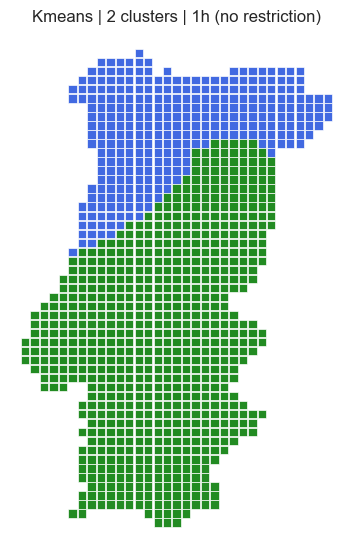

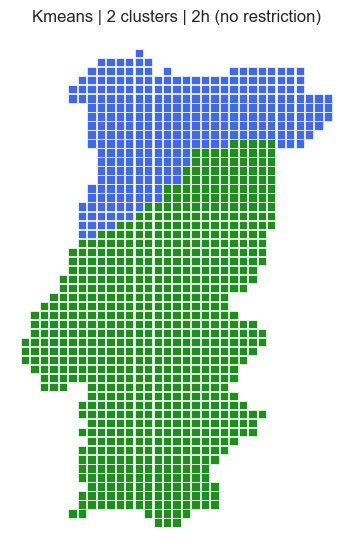

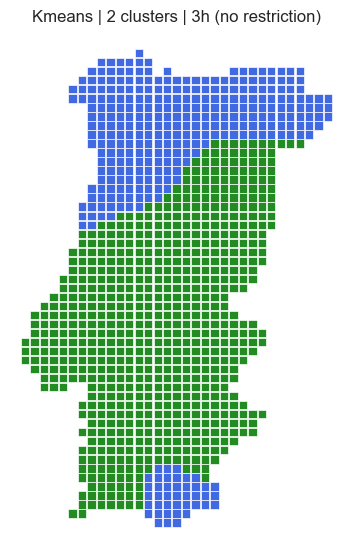

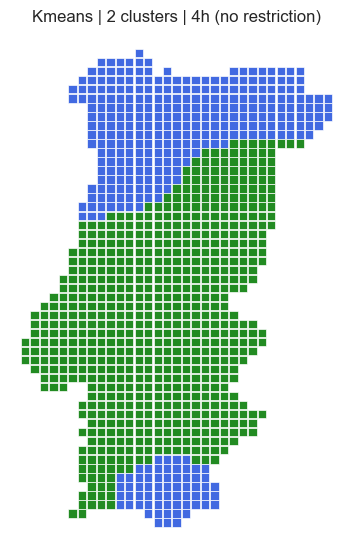

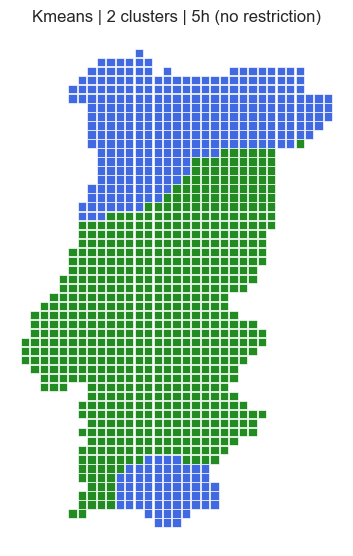

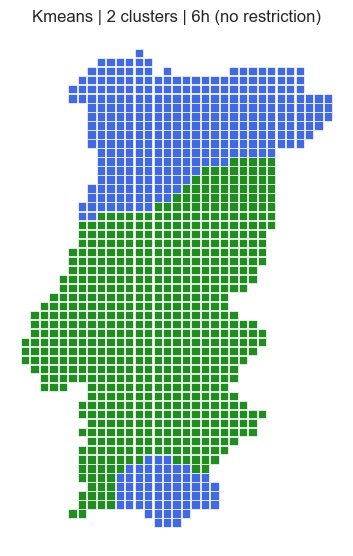

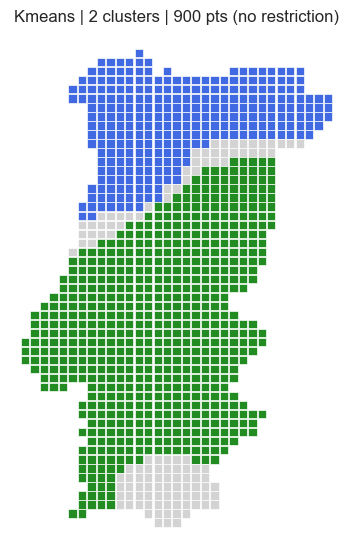

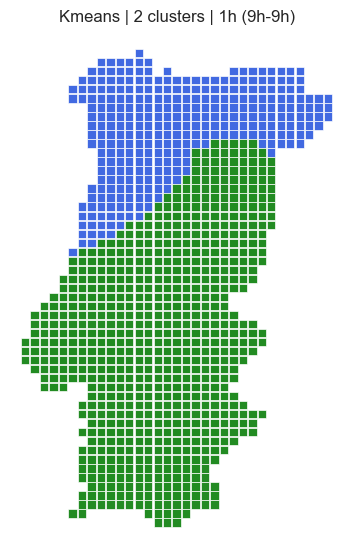

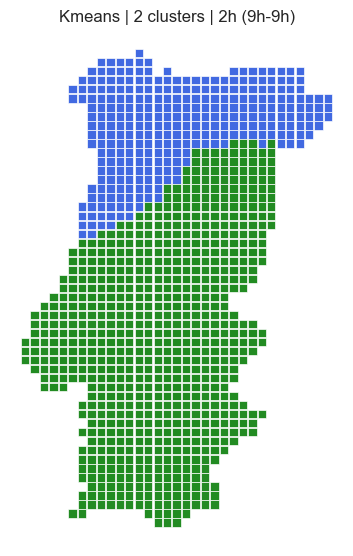

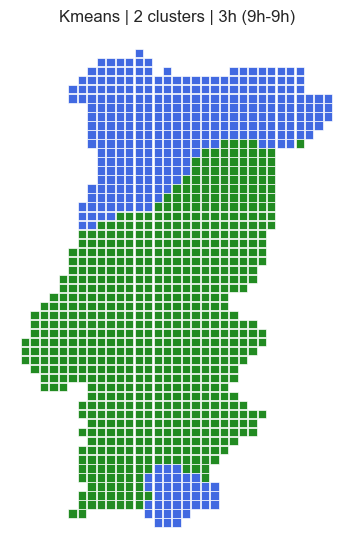

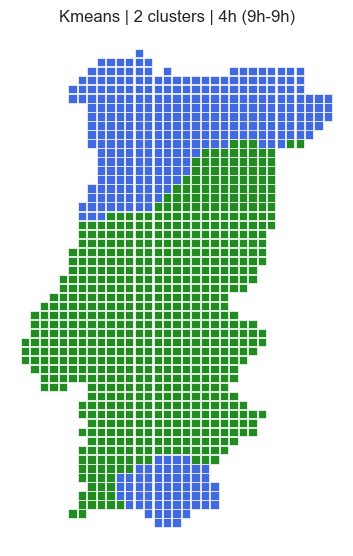

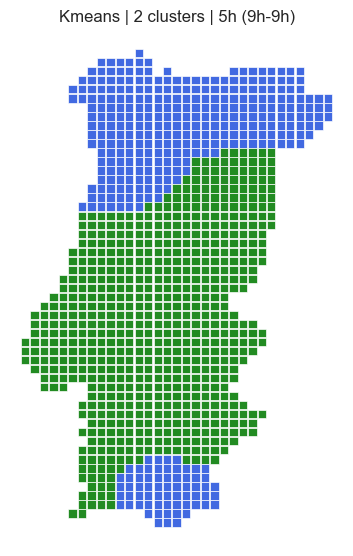

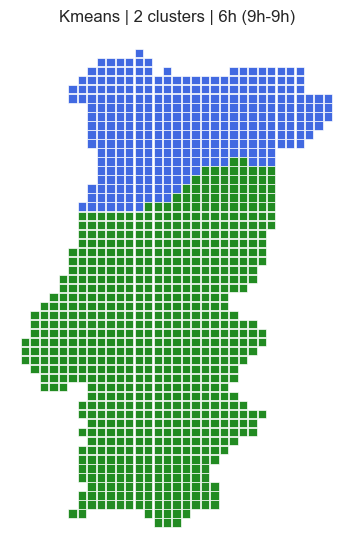

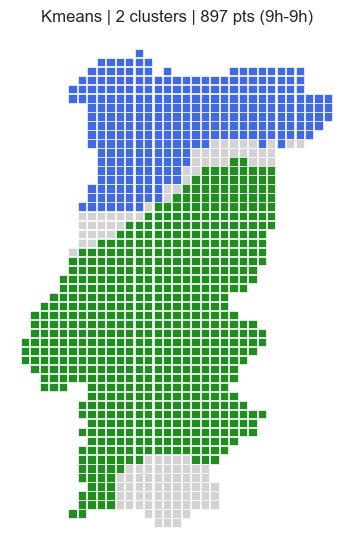

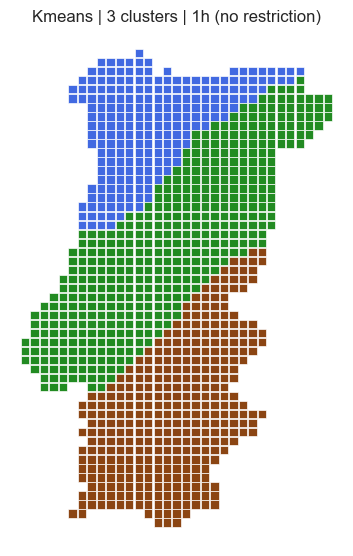

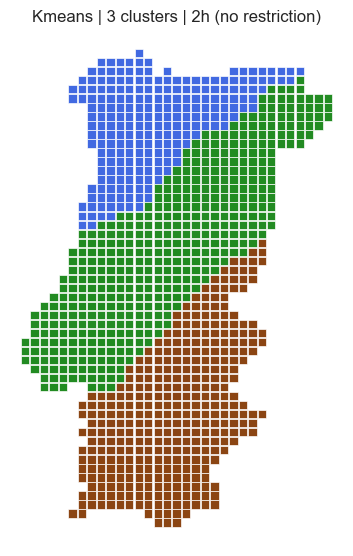

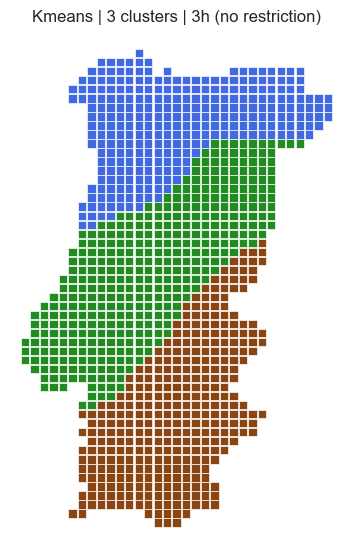

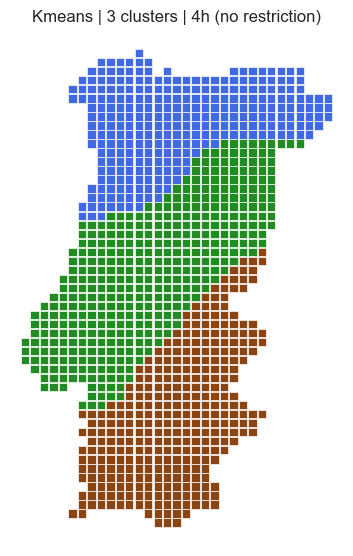

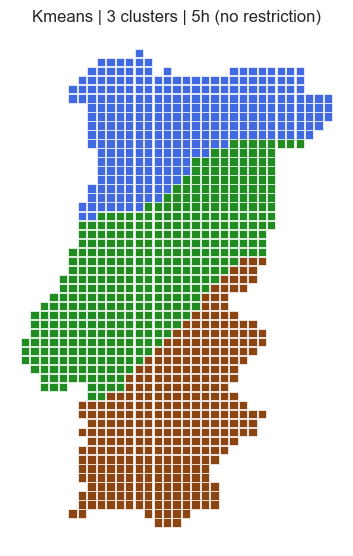

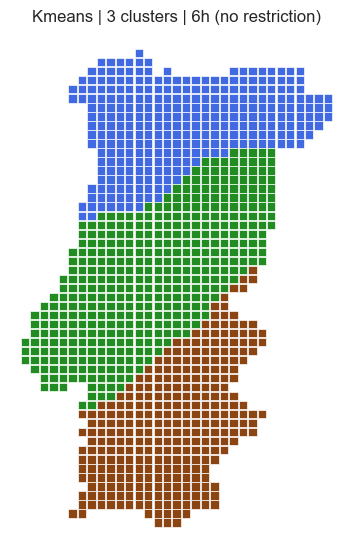

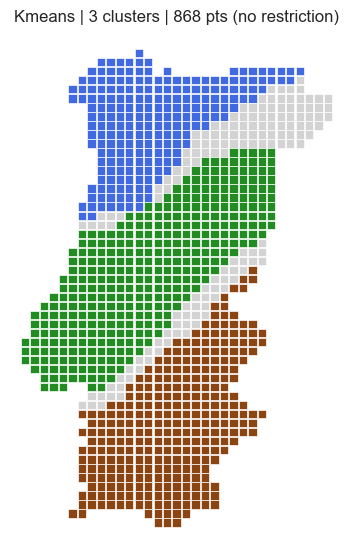

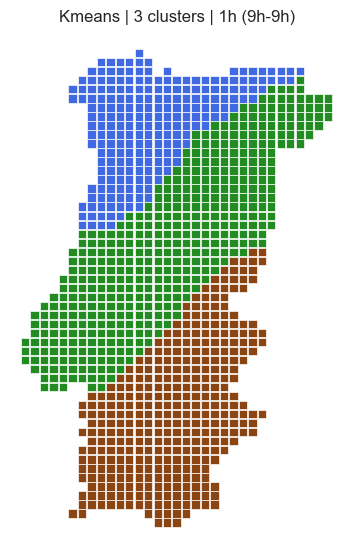

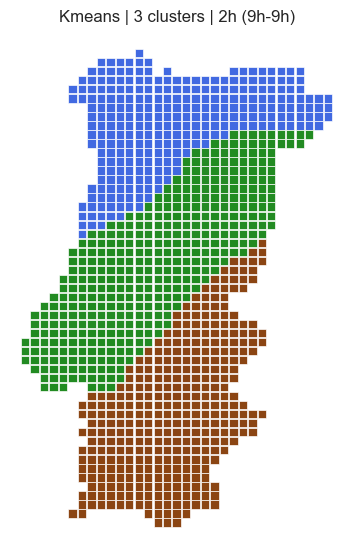

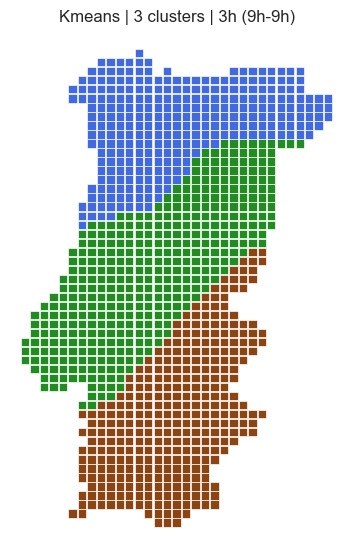

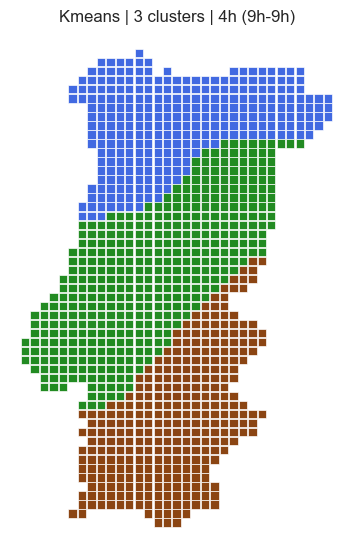

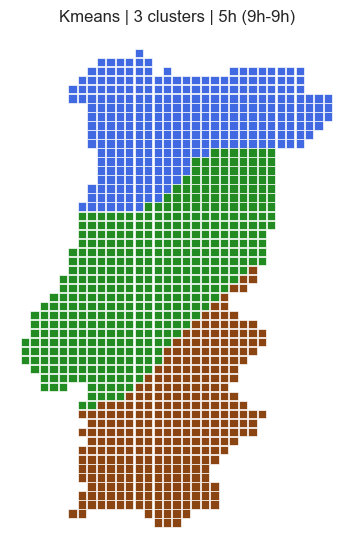

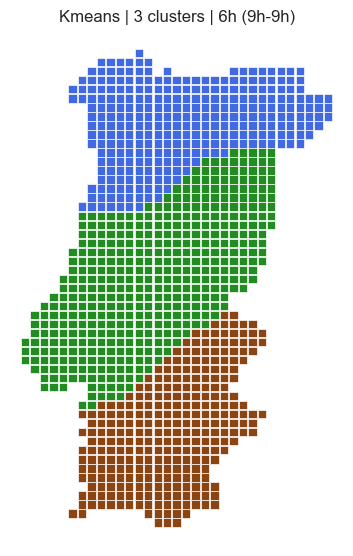

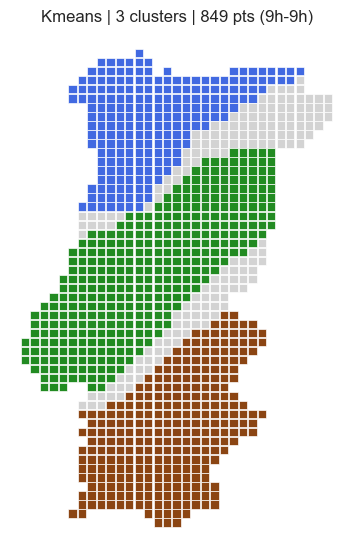

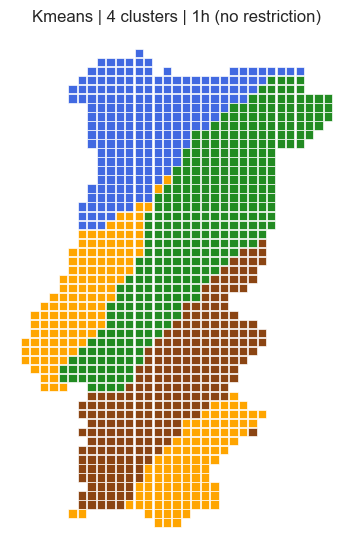

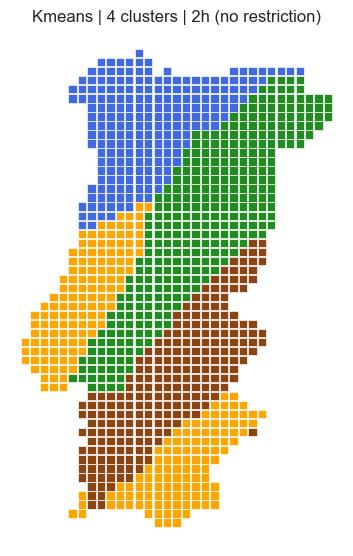

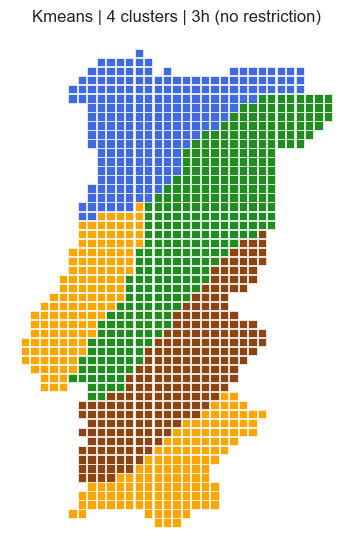

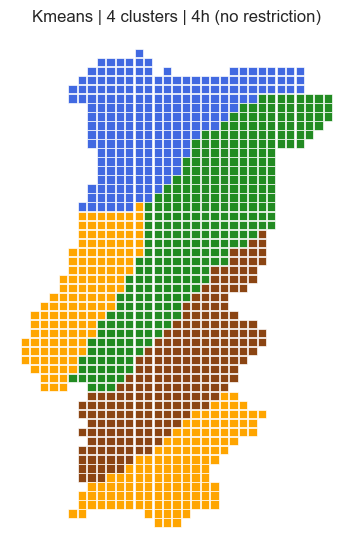

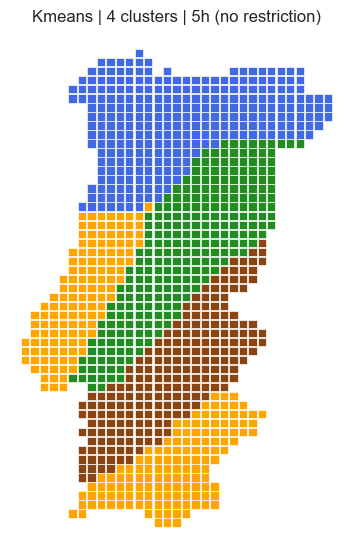

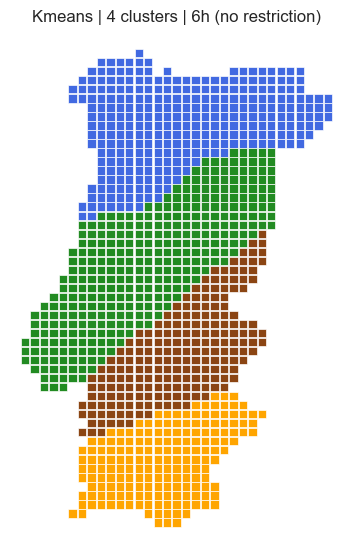

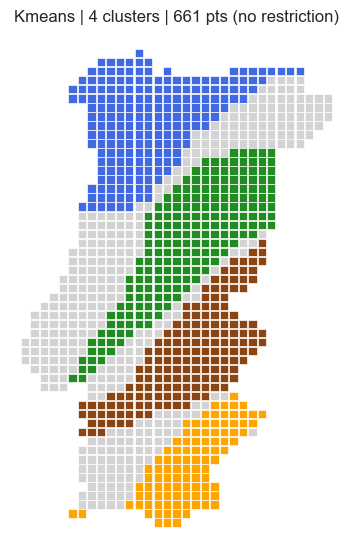

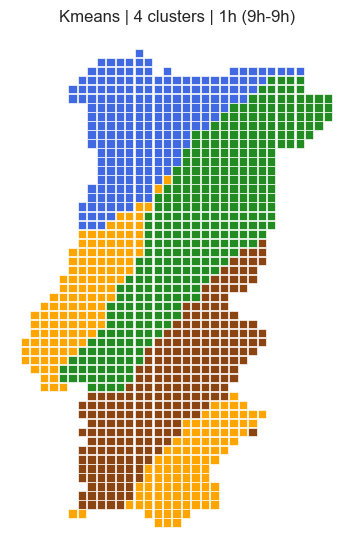

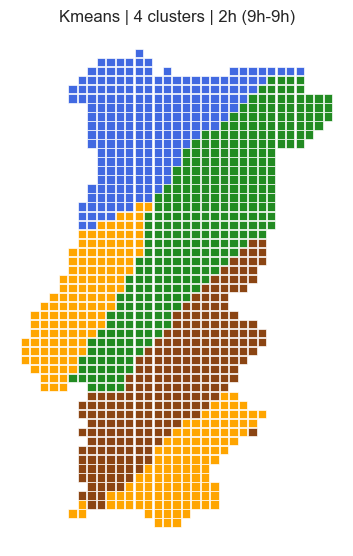

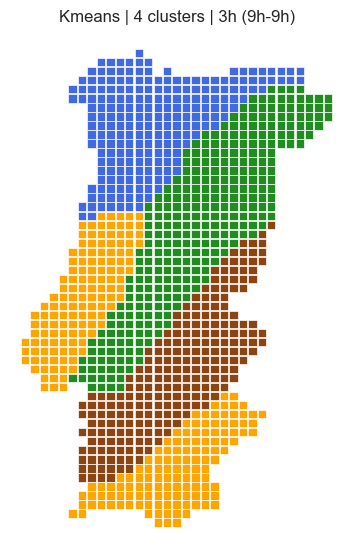

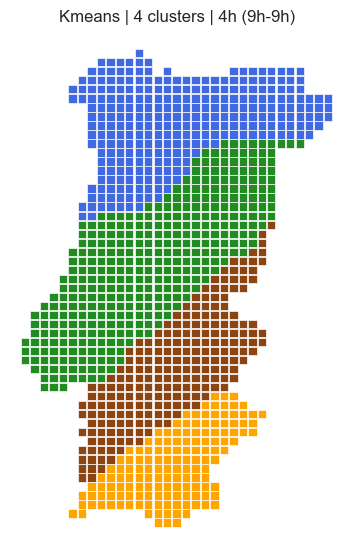

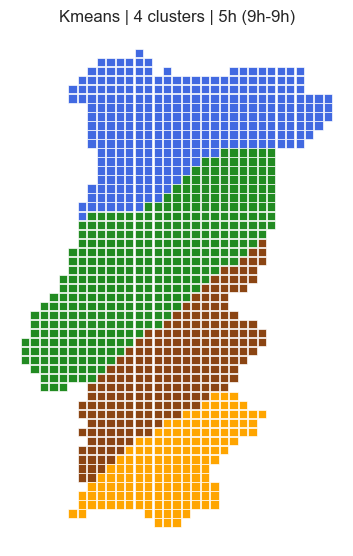

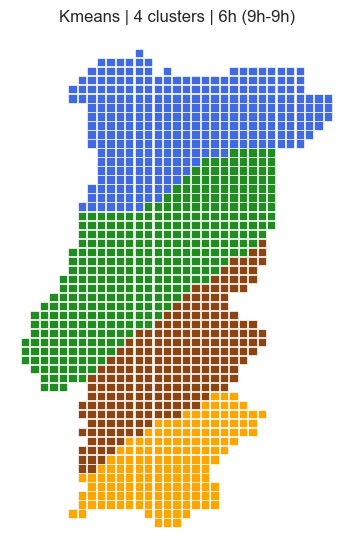

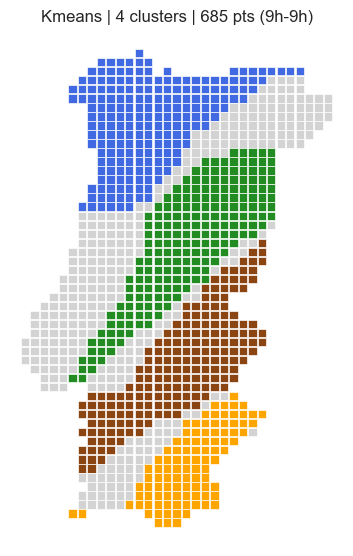

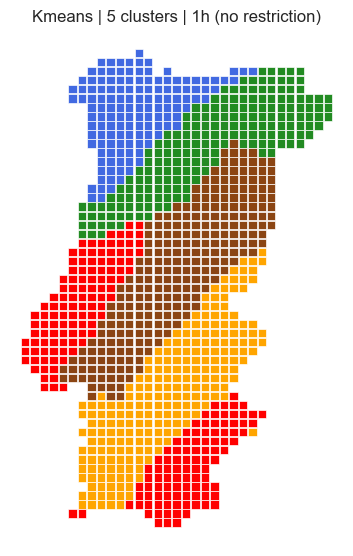

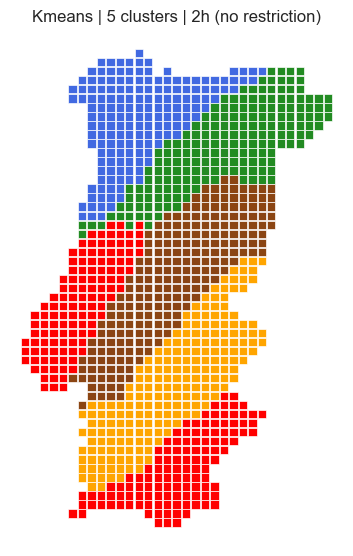

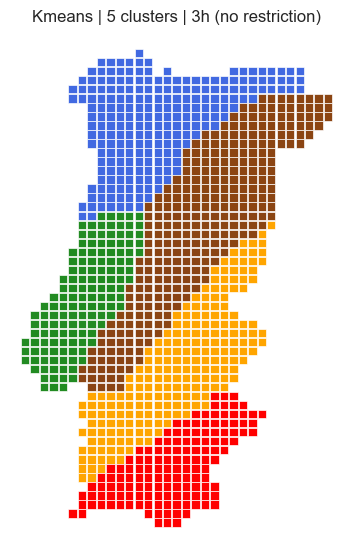

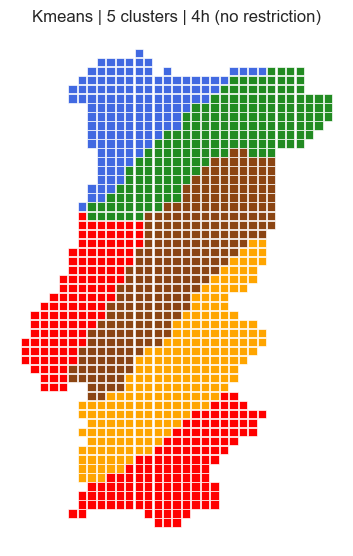

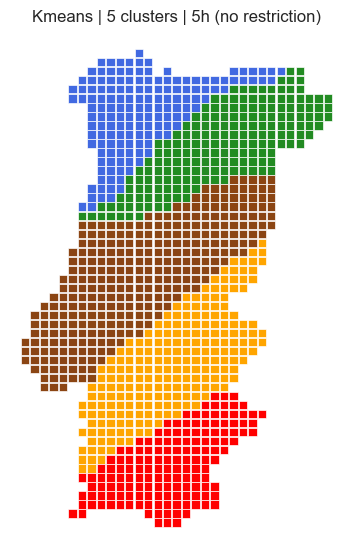

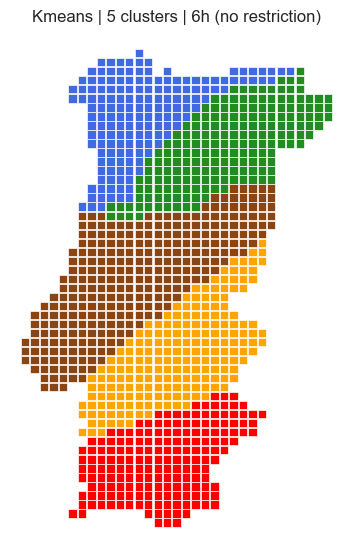

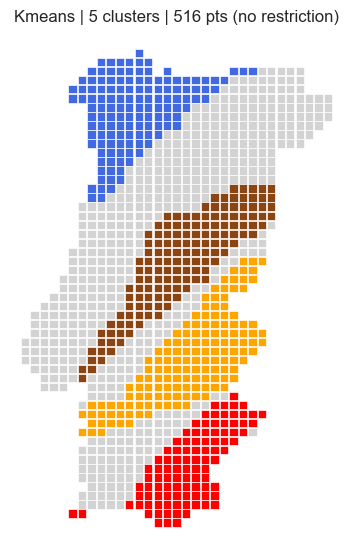

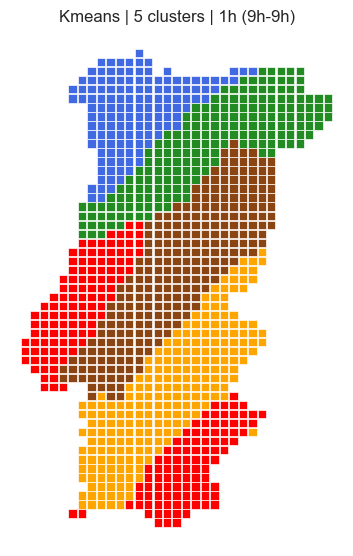

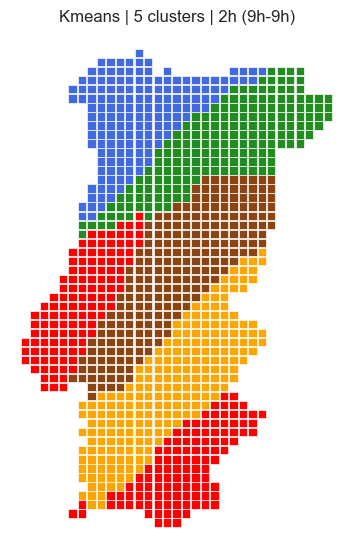

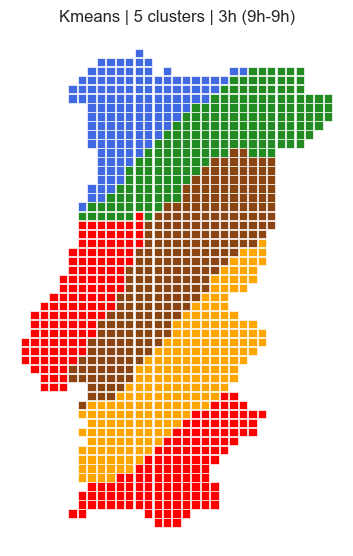

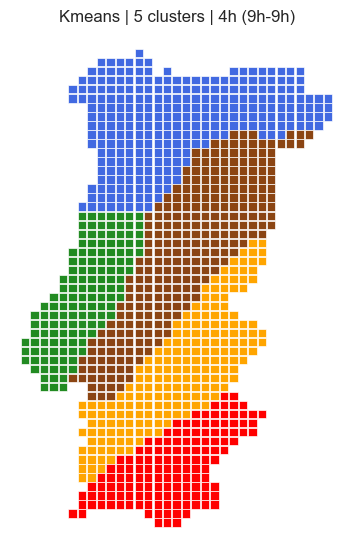

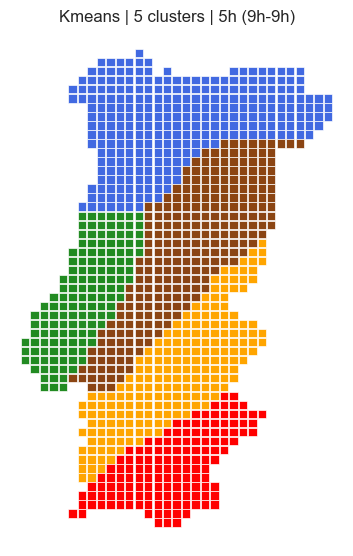

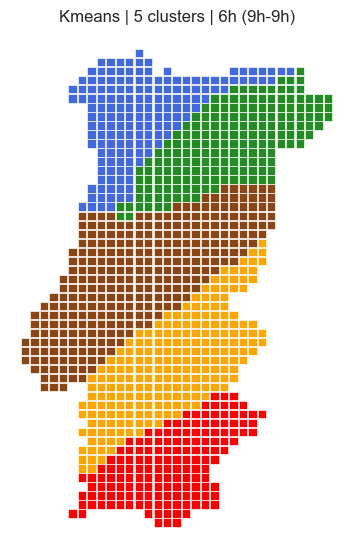

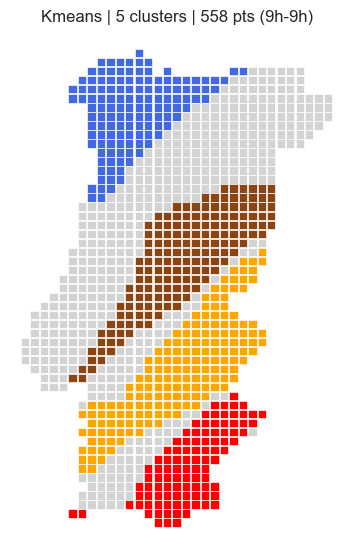

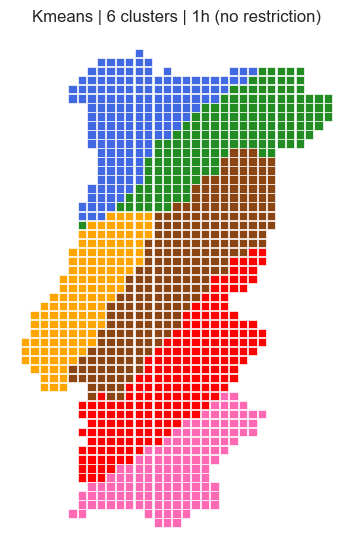

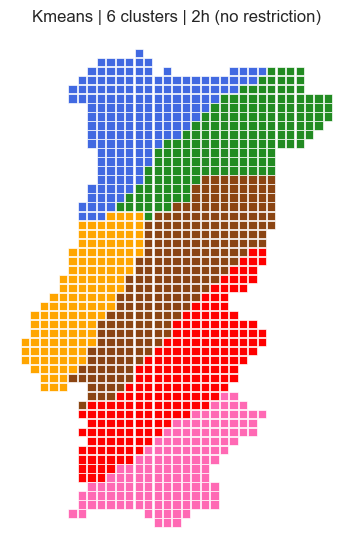

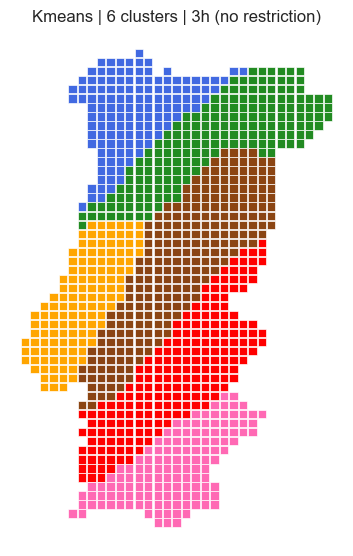

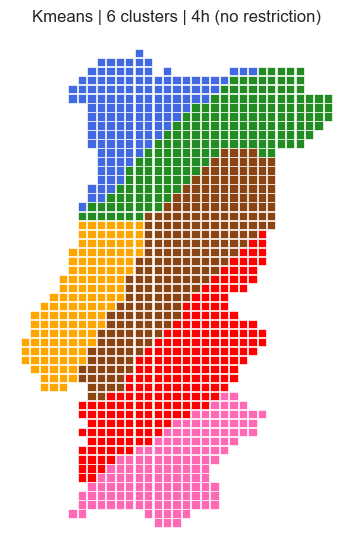

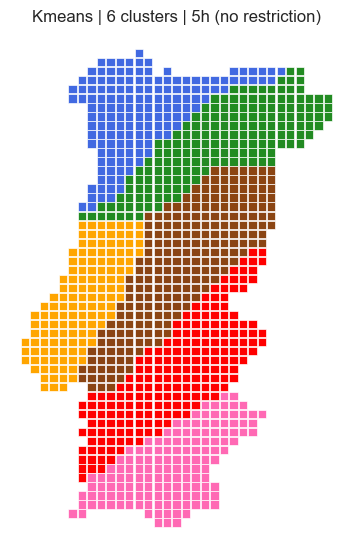

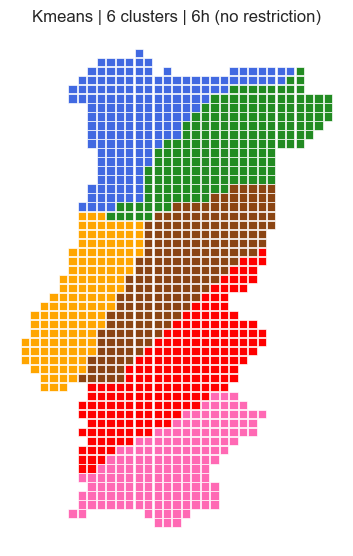

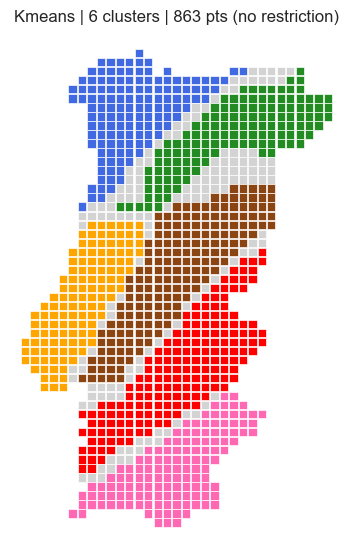

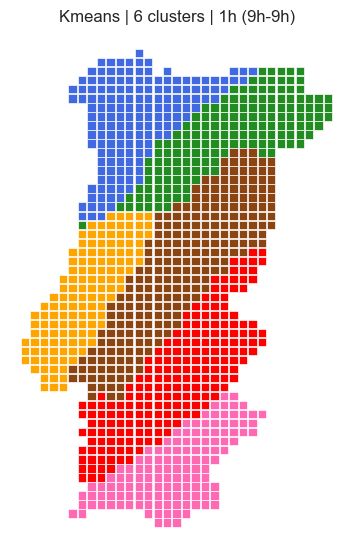

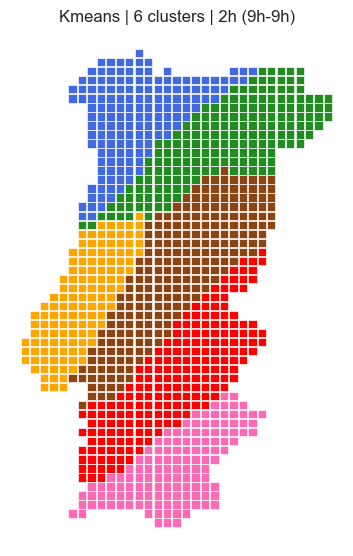

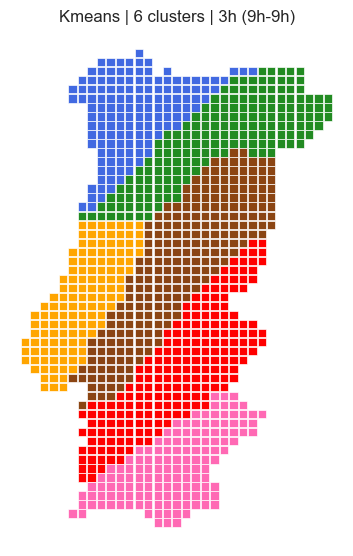

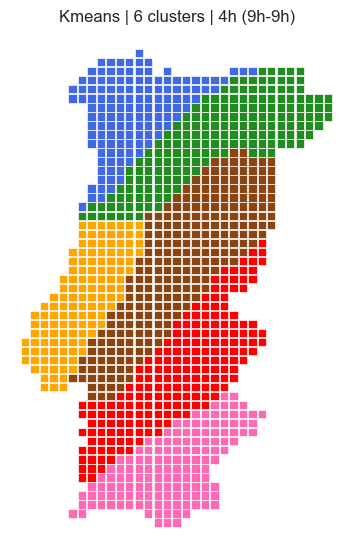

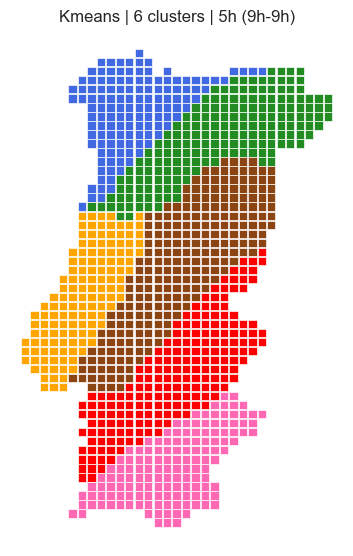

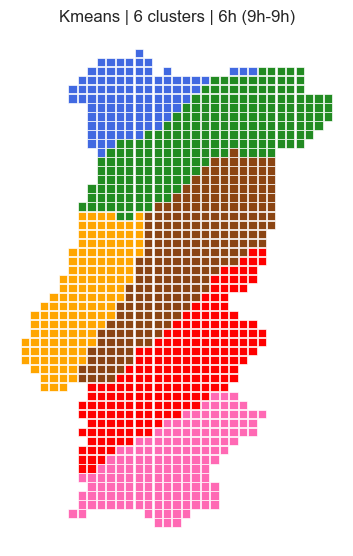

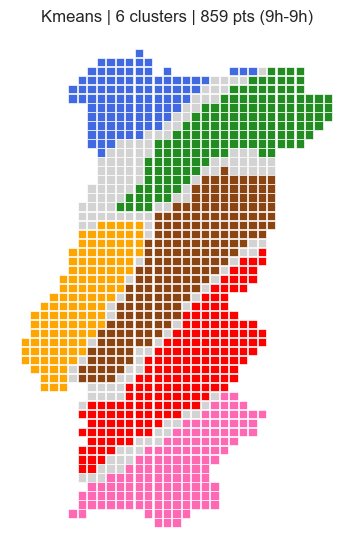

In [8]:
# Folder that stores the saved plots
folder = r"C:\Users\joaoa\Desktop\plots"
    
# Visualization
for n in K:
    for t in T:

        seq_clusters[t][n] = seq_clusters[t][n].reset_index(drop = True)
        df_plot = pd.concat([local, seq_clusters[t][n]], axis = 1)

        # Plotting clusters       
        for h in H:
            
            if (n == 5 and t == "no restriction" and h == 3):
                palette_1 = ["royalblue", "saddlebrown", "forestgreen", "orange", "red", "hotpink"]
            elif (n == 4 and ((t == "no restriction" and h <= 5) or (t == "9h-9h" and h <= 3))) or (n == 6 and t == "9h-9h" and h in [8,10,12,16,20,24]) or (n == 5 and t == "no restriction" and h == 24):
                palette_1 = ["royalblue", "forestgreen", "orange", "saddlebrown", "red", "hotpink"]
            elif n == 5 and ((t == "no restriction" and h in [1,2,4]) or (t == "9h-9h" and h <= 3)):
                palette_1 = ["royalblue", "forestgreen", "saddlebrown", "red", "orange", "hotpink"]
            elif (n == 5 and t == "9h-9h" and h in [4,5]):
                palette_1 = ["royalblue", "saddlebrown", "forestgreen", "orange", "red", "hotpink"]
            elif n == 6 and h == 72:
                palette_1 = ["royalblue", "forestgreen", "saddlebrown", "red", "orange", "hotpink"]
            else:
                palette_1 = ["royalblue", "forestgreen", "saddlebrown", "orange", "red", "hotpink", "black"]
            
            sns.set_theme(style = 'white')
            sns.relplot(data = df_plot, x = "longitude", y = "latitude", hue = "clusters_" + str(n) + " | " + str(h) + "h (" + t + ")", palette = palette_1, marker = "s", height = 6, aspect = 0.7, legend = False).set(title = "Kmeans | " + str(n) + " clusters" + " | " + str(h) + "h (" + t + ")")
            plt.axis("off")
            plt.savefig(folder + "\kmeans_part1_" + str(n) + "_clusters_" + str(h) + "h_(" + t + ").png", bbox_inches = 'tight')
            plt.show()

        # Plotting commun area
        
        if n == 5:
            palette_2 = ["royalblue", "lightgrey", "saddlebrown", "orange", "red", "forestgreen", "hotpink"]
        else:
            palette_2 = ["royalblue", "lightgrey", "forestgreen", "saddlebrown", "orange", "red", "hotpink", "black"]
        
        sns.set_theme(style = 'white')
        sns.relplot(data = df_plot, x = "longitude", y = "latitude", hue = "commun", palette = palette_2, marker = "s", height = 6, aspect = 0.7, legend = False).set(title = "Kmeans | " + str(n) + " clusters" + " | " + str(commun_points[t][n]) + " pts (" + t + ")")
        plt.axis("off")
        plt.savefig(folder + "\kmeans_part1_" + str(n) + "_clusters_commun_(" + t + ").png", bbox_inches = 'tight')
        plt.show()

2 clusters   |   no restriction   |   Number of commun points: 900


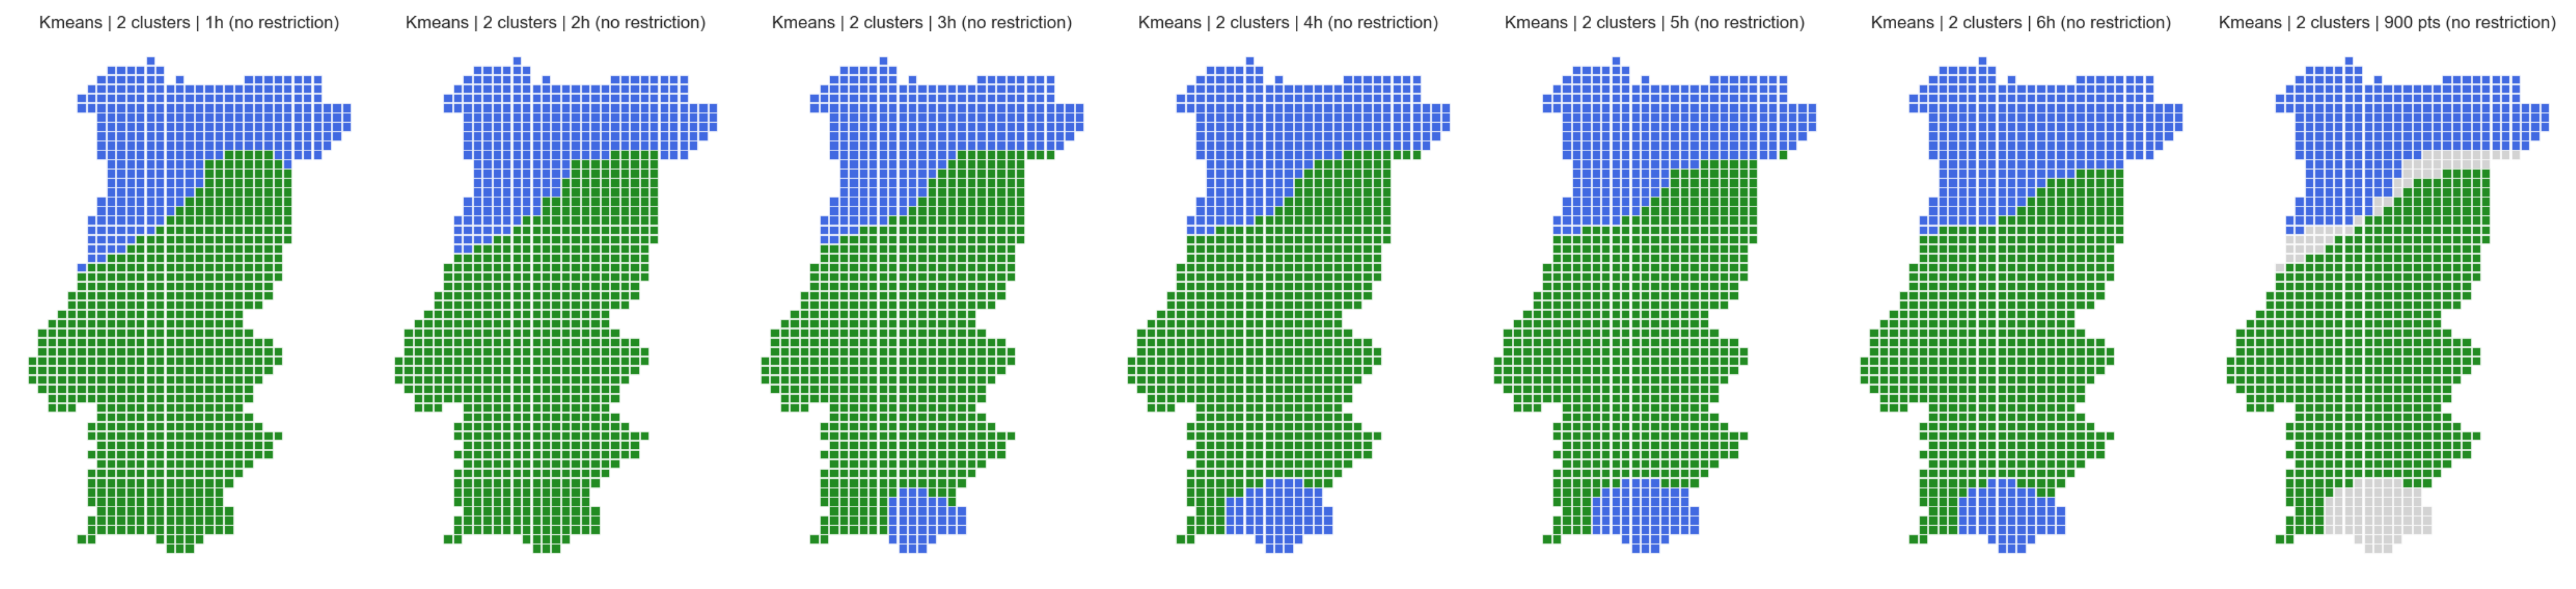

2 clusters   |   9h-9h   |   Number of commun points: 897


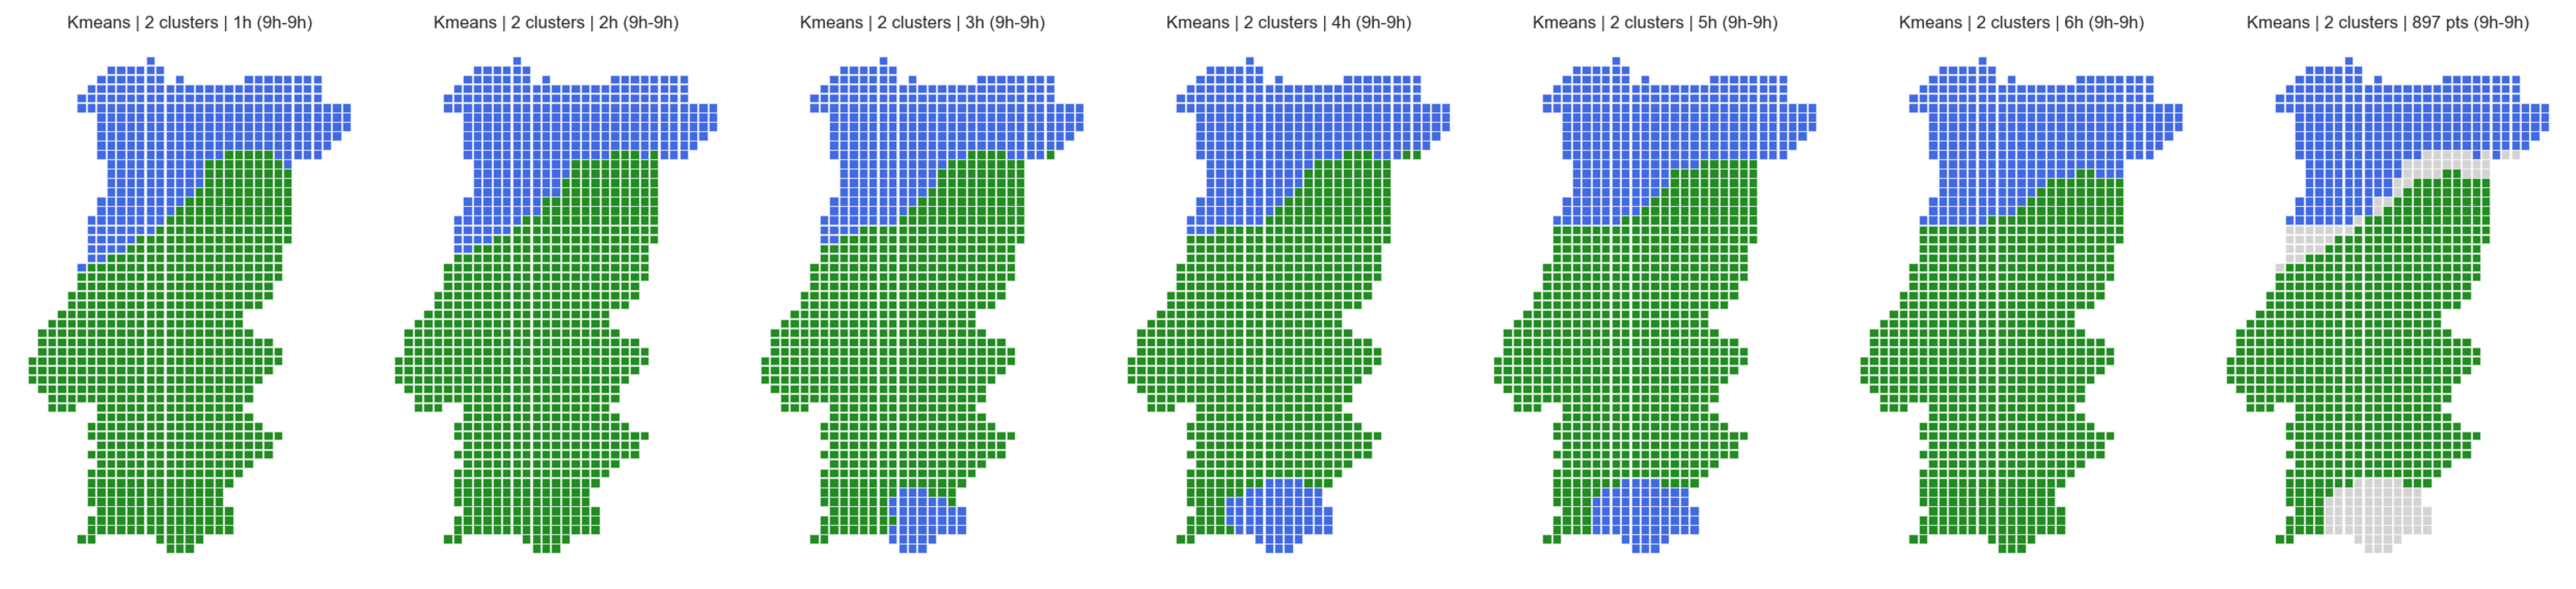

3 clusters   |   no restriction   |   Number of commun points: 868


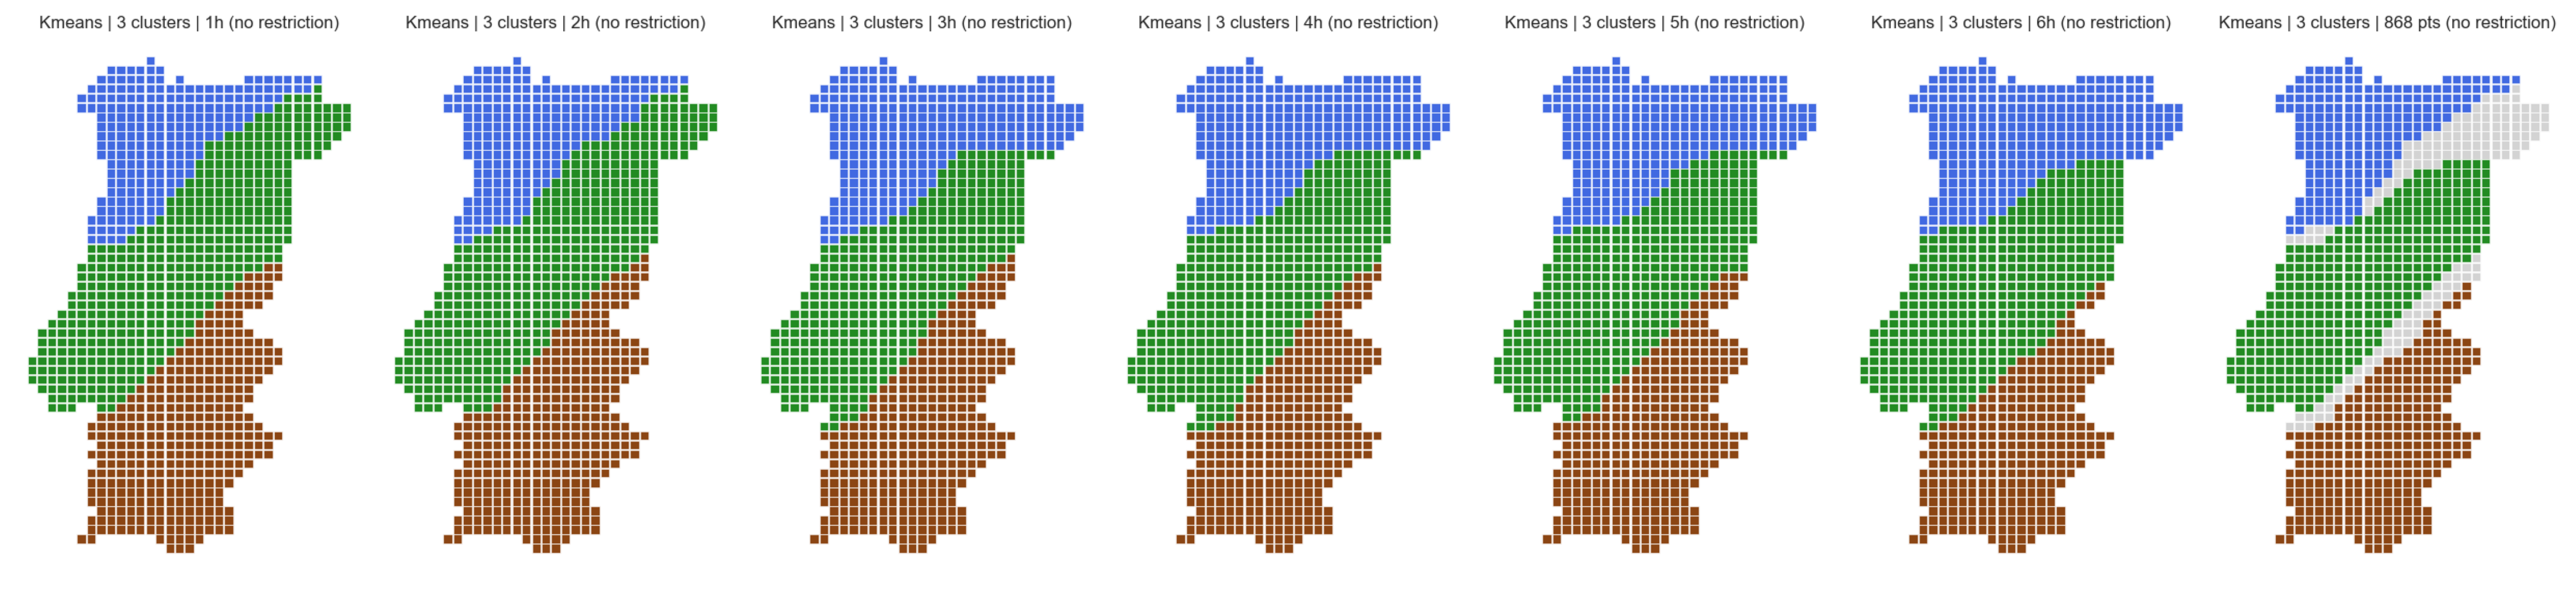

3 clusters   |   9h-9h   |   Number of commun points: 849


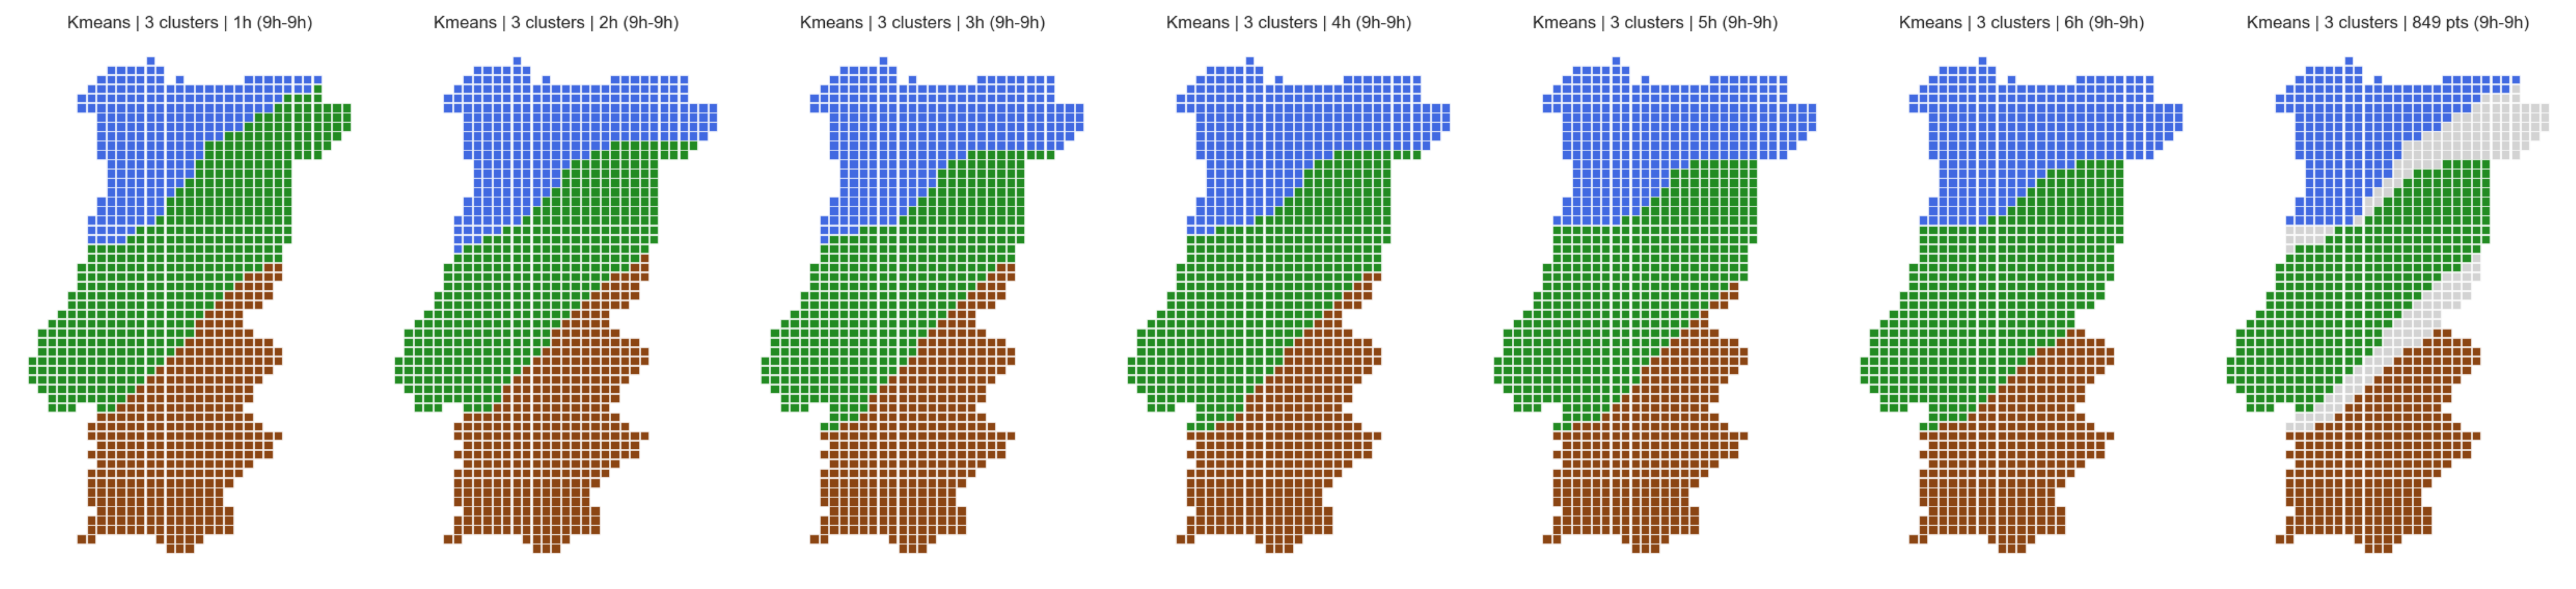

4 clusters   |   no restriction   |   Number of commun points: 661


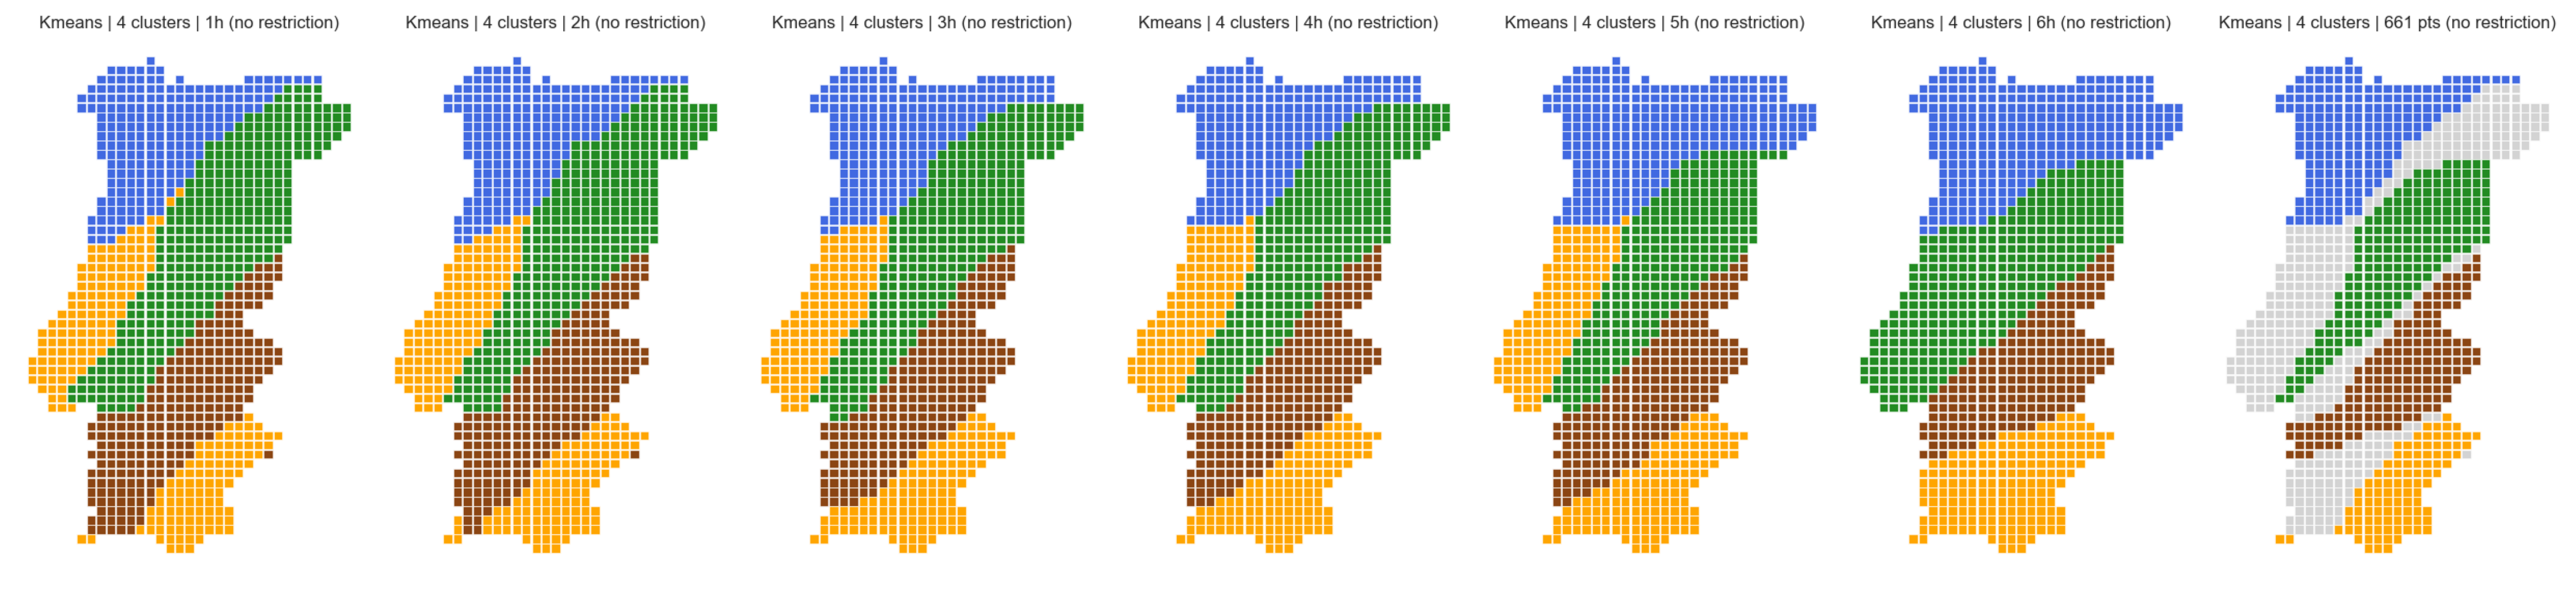

4 clusters   |   9h-9h   |   Number of commun points: 685


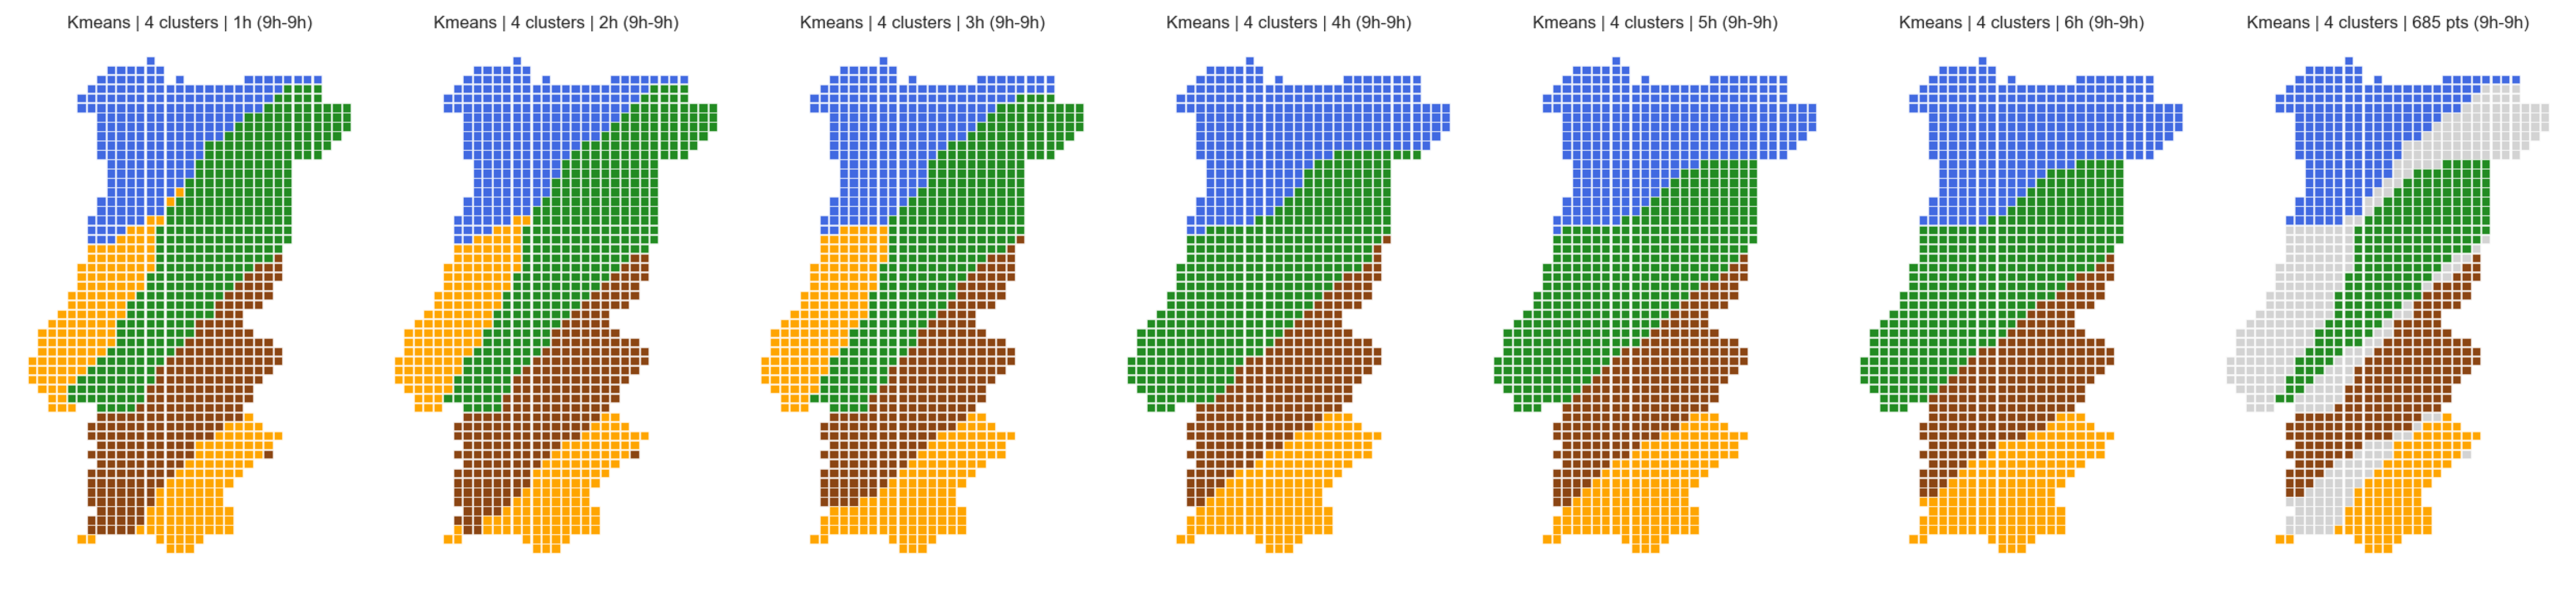

5 clusters   |   no restriction   |   Number of commun points: 516


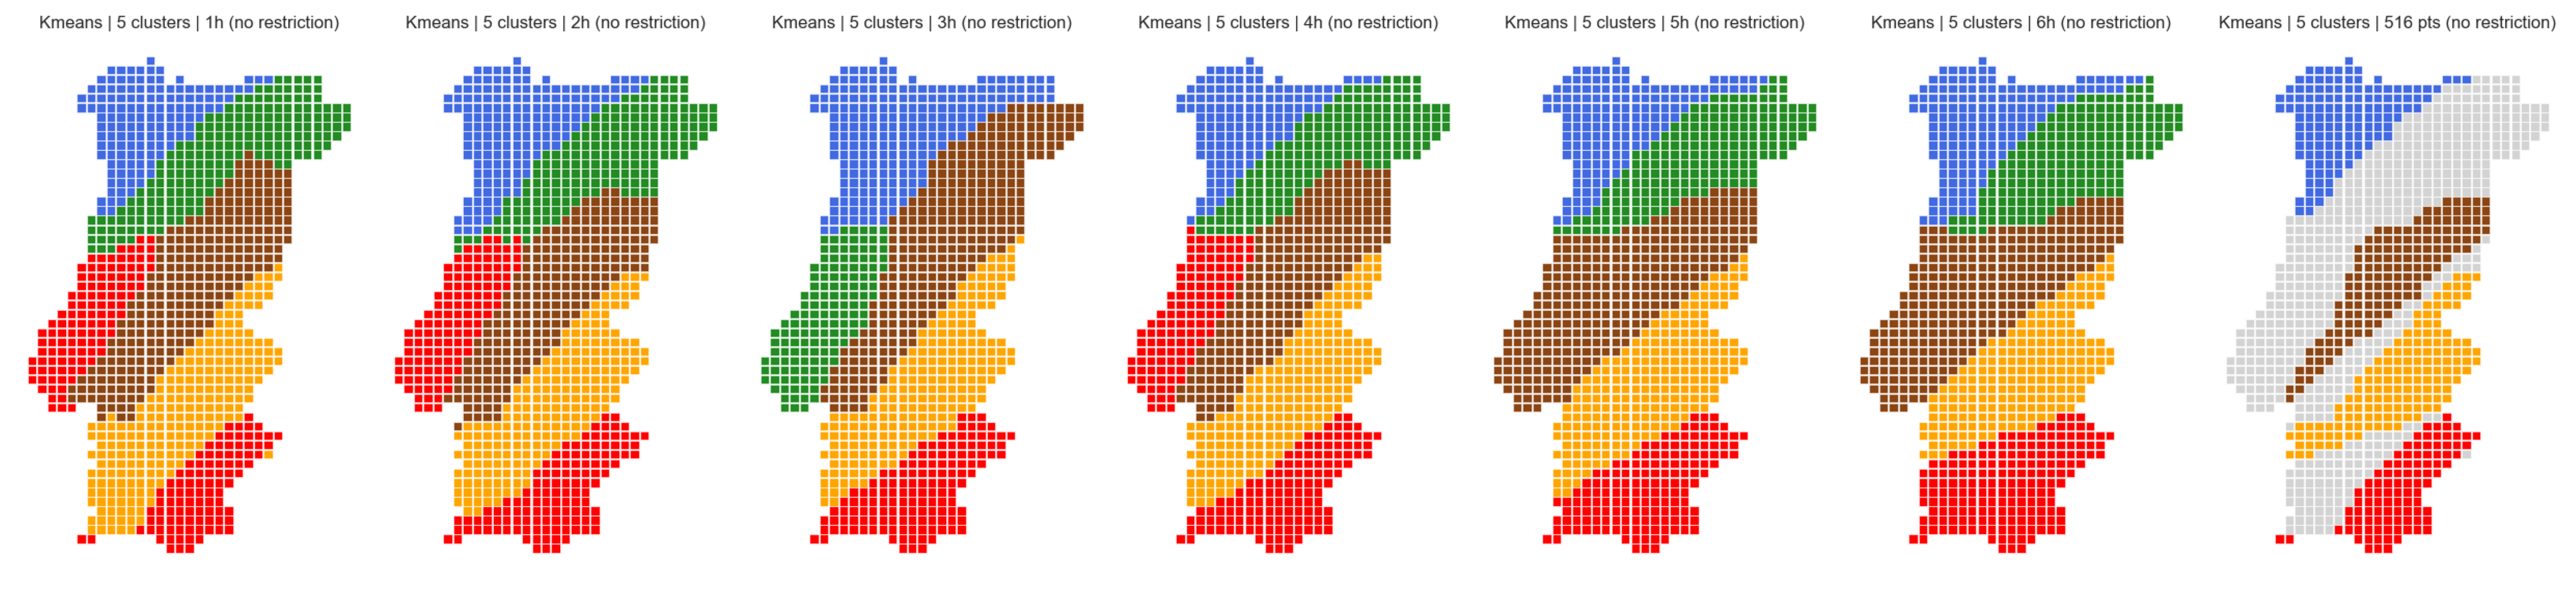

5 clusters   |   9h-9h   |   Number of commun points: 558


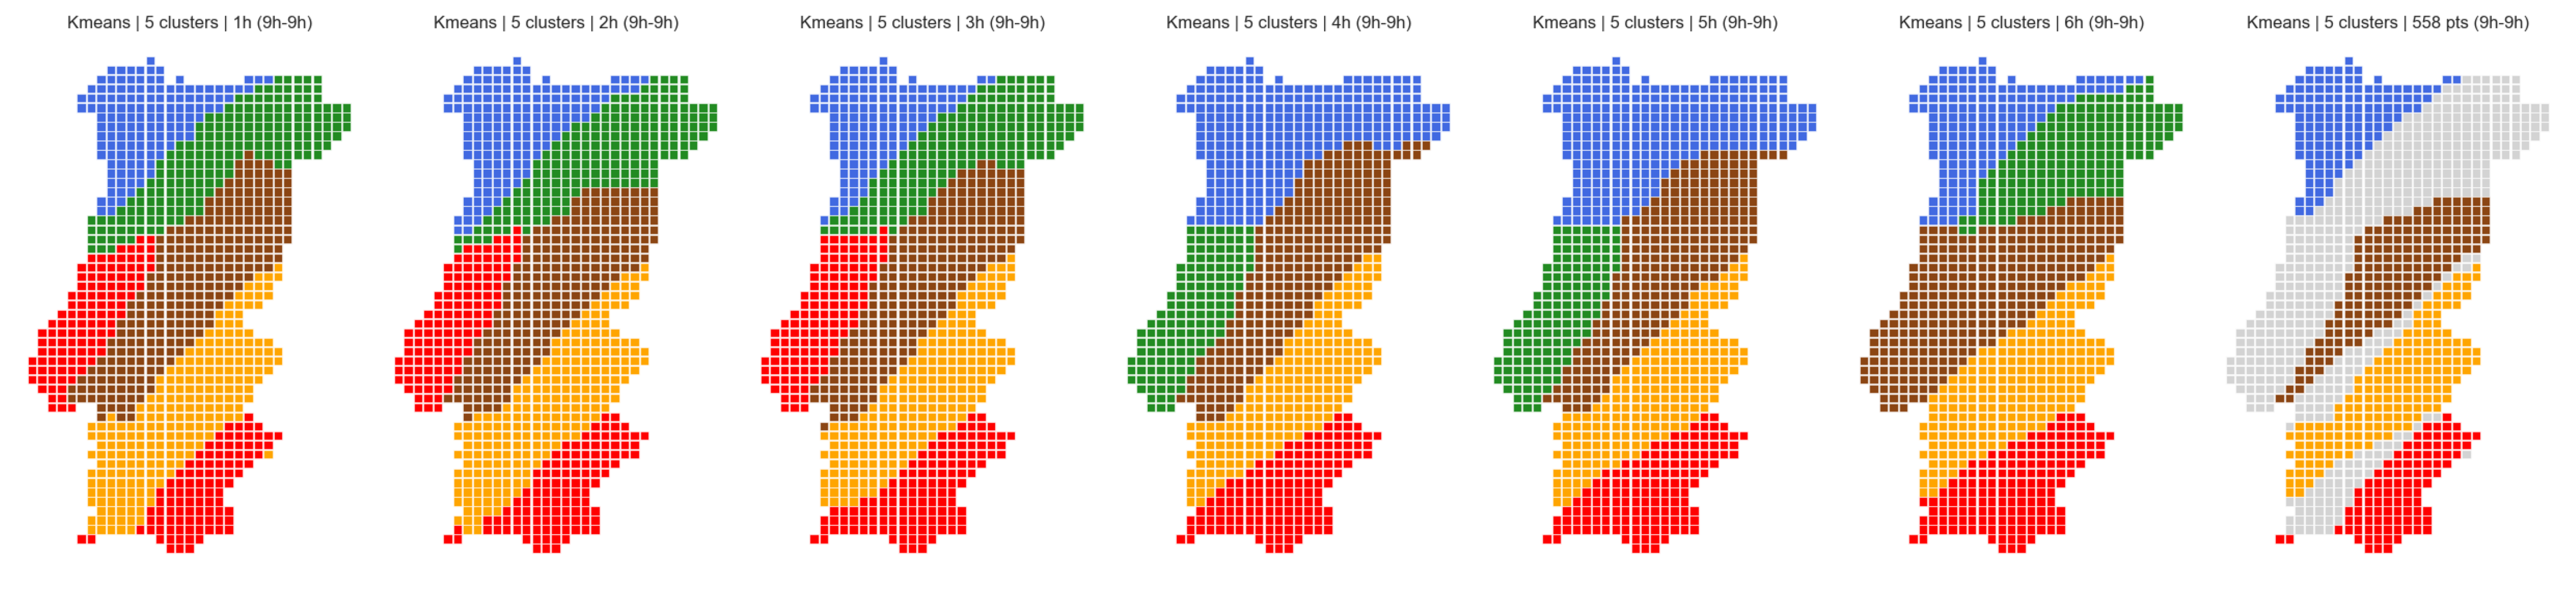

6 clusters   |   no restriction   |   Number of commun points: 863


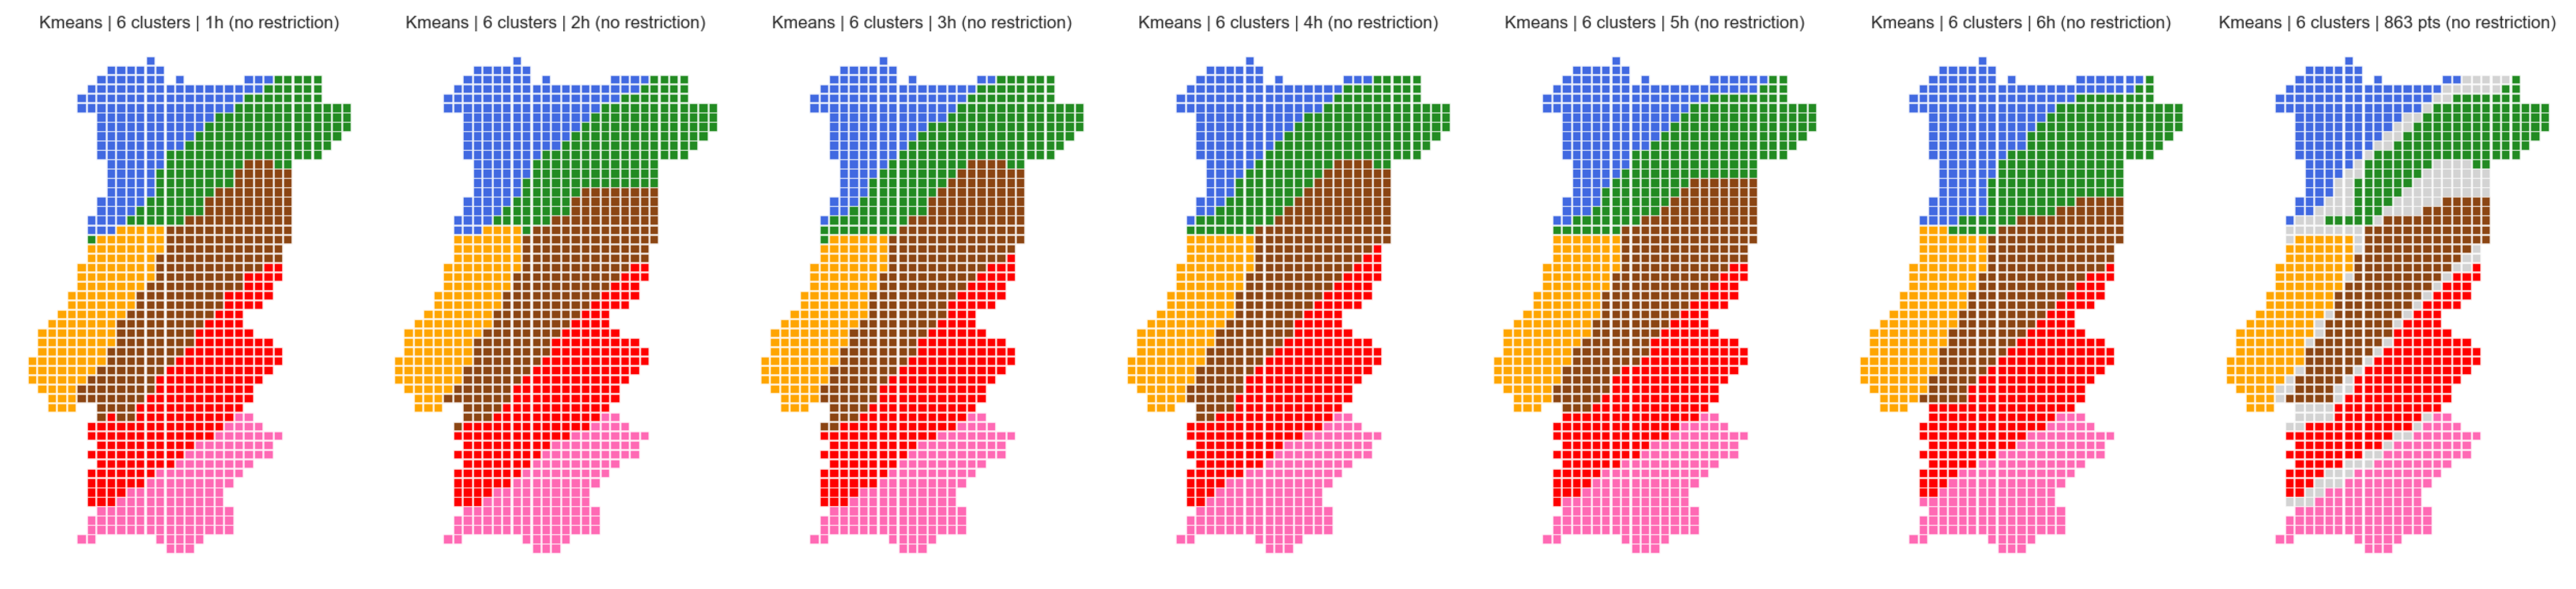

6 clusters   |   9h-9h   |   Number of commun points: 859


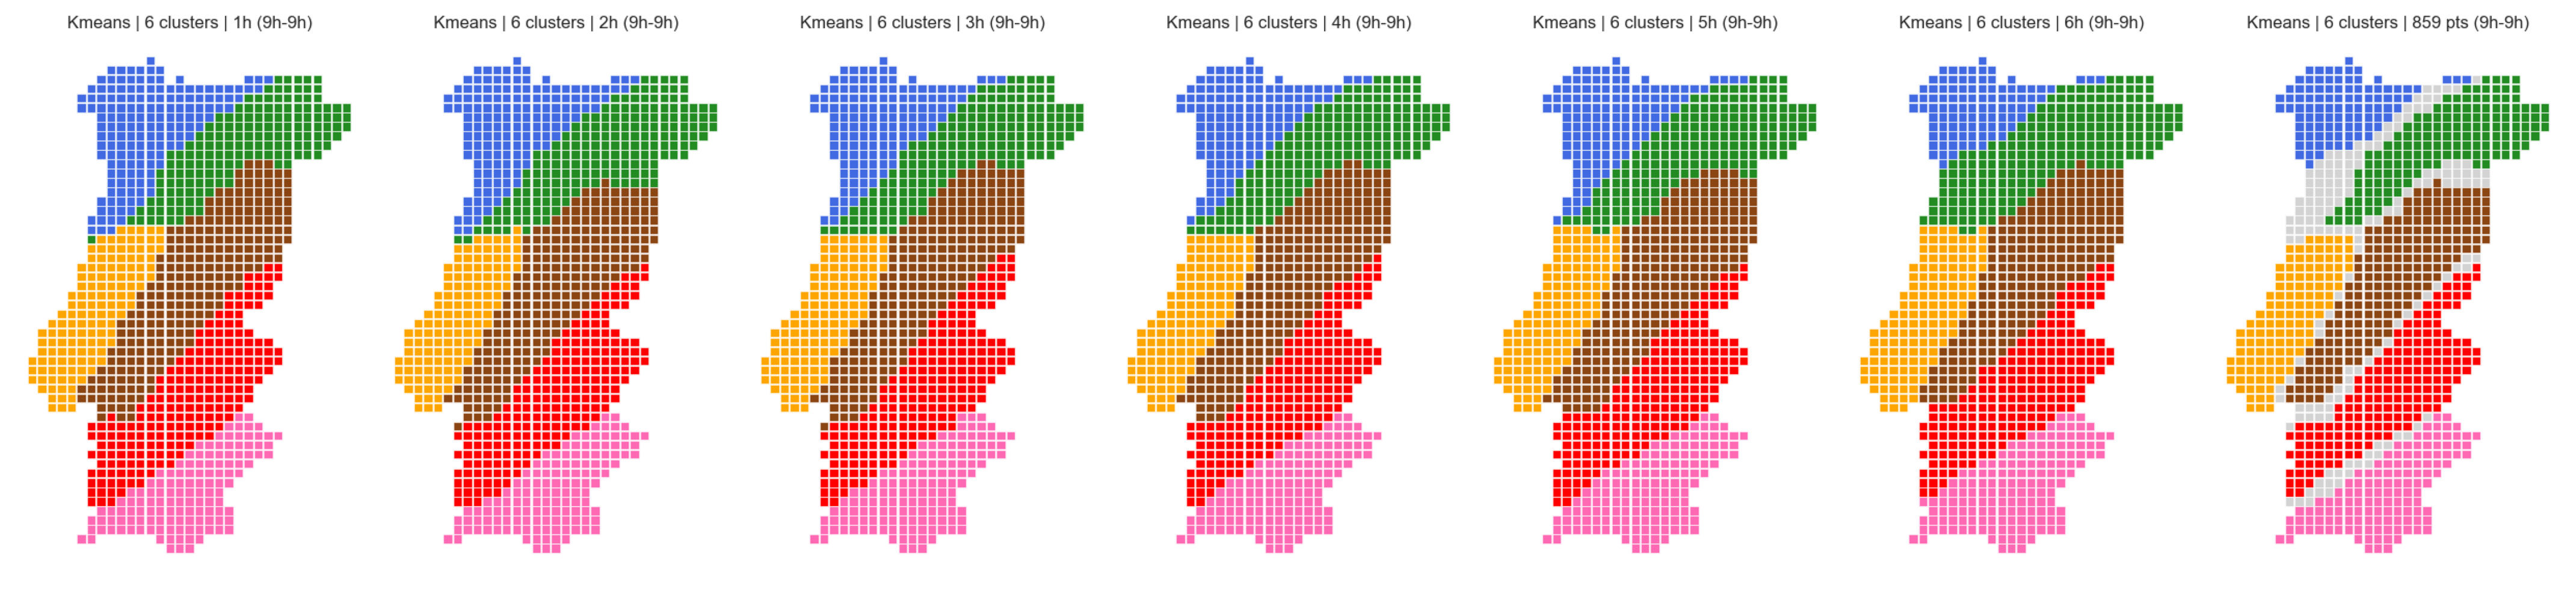

In [9]:
for n in K:
    for t in T:

        seq_clusters[t][n] = seq_clusters[t][n].reset_index(drop = True)
        df_plot = pd.concat([local, seq_clusters[t][n]], axis = 1)

        fig = plt.figure(figsize = (55, 55))
        columns = len(H) + 1
        rows = 1
        i = 0

        for h in H:
            i += 1
            img = Image.open(folder + "\kmeans_part1_" + str(n) + "_clusters_" + str(h) + "h_(" + t + ").png")
            fig.add_subplot(rows, columns, i)
            plt.subplots_adjust(wspace = 0, hspace = 0)
            plt.axis("off")
            plt.imshow(img)

        i += 1
        img = Image.open(folder + "\kmeans_part1_" + str(n) + "_clusters_commun_(" + t + ").png")
        fig.add_subplot(rows, columns, i)
        plt.subplots_adjust(wspace = 0, hspace = 0)
        plt.axis("off")
        plt.imshow(img)
        
        print(str(n) + " clusters   |   " + t + "   |   Number of commun points:", commun_points[t][n])
        plt.savefig(folder + "\kmeans_part1_" + str(n) + "_clusters_all_maps_(" + t + ").png", bbox_inches = 'tight')
        plt.show()